In [1]:
import pandas as pd

df = pd.read_csv('../data/bank-full.csv', sep=';')

In [2]:
#Drop fitur duration karena mengandung target leakage
df = df.drop(columns=['duration'])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [3]:
# Ini perlu jadi 2 fitur, bukan 1 — biar model bisa bedakan "belum pernah dikontak" vs "skala hari"
df['was_contacted_before'] = (df['pdays'] != -1).astype(int)
df['pdays_clean'] = df['pdays'].replace(-1, 0)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,was_contacted_before,pdays_clean
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no,0,0


Kenapa ga pake `-1` mentah ke model, kalo dibiarkan model akan salah interapreatasi seolah `-1` itu lebih kecil padahal `-1` hanyalah kode untuk orang yang belum dihubungi sebelumnya

<Axes: xlabel='day'>

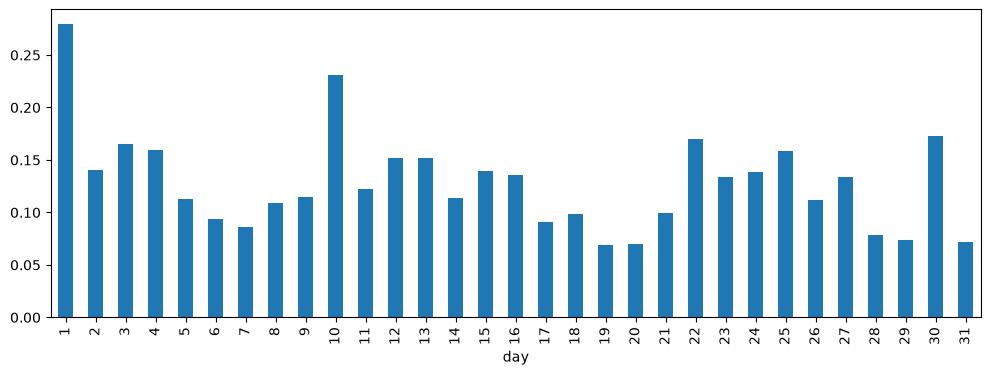

In [4]:
df.groupby('day')['y'].apply(lambda x: (x=='yes').mean()).plot(kind='bar', figsize=(12,4))

Kolom `day` di-drop karena visualisasi subscribe rate per tanggal tidak menunjukkan tren linear maupun pola siklikal yang jelas. Variasinya cenderung acak, mengindikasikan day lebih merupakan faktor operasional (kapan staff bisa menelpon) dibanding sinyal perilaku nasabah. Memperlakukannya sebagai numerik linear berisiko menyesatkan model, khususnya Logistic Regression yang sensitif terhadap asumsi skala.

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['y','day','pdays'])
y = df['y'].map({'yes': 1, 'no': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = ['age', 'balance', 'campaign', 'pdays_clean', 'previous']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
# was_contacted_before udah 0/1, gak perlu di-encode lagi

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

In [7]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

(36168, 40)
(9043, 40)


In [8]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_transformed, y_train)
y_pred_dummy = dummy.predict(X_test_transformed)

print("Dummy Accuracy:", dummy.score(X_test_transformed, y_test))

Dummy Accuracy: 0.8830034280659074


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_transformed, y_train)

y_pred_lr = logreg.predict(X_test_transformed)
y_proba_lr = logreg.predict_proba(X_test_transformed)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.63      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043

AUC-ROC: 0.7721662071961487
[[6172 1813]
 [ 396  662]]


Total aktual `yes` di test set: total yes = FN + TP = 396 + 662 = 1058 (cocok sama support kelas 1 di atas). Artinya dari 1058 nasabah yang sebenarnya bakal subscribe, model menangkap 662 (63%) dan melewatkan 396 (37%). 

Kalau bank cuma punya budget buat nelpon 2476 orang (sesuai jumlah yang model prediksi yes), dan 662 dari mereka beneran subscribe, 
apakah ini lebih efisien dibanding nelpon semua nasabah secara acak (yang rate suksesnya cuma 11.7%)? 

In [10]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel().tolist()
random_success = 2476 * 0.117
print(f"Jika staf menghubungi orang secara acak: {round(random_success)}" )
print(f"Jika staf menghubungi orang menggunakan rekomendasi model: {tp}" )
model_precision = 662 / 2476
lift = model_precision / 0.117
print(f"Gain yang didapatkan jika menggunakan rekomendasi model: {lift:.2f}" )


Jika staf menghubungi orang secara acak: 290
Jika staf menghubungi orang menggunakan rekomendasi model: 662
Gain yang didapatkan jika menggunakan rekomendasi model: 2.29


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_transformed, y_train)

y_pred_rf = rf.predict(X_test_transformed)
y_proba_rf = rf.predict_proba(X_test_transformed)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      7985
           1       0.44      0.39      0.41      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.66      0.67      9043
weighted avg       0.86      0.87      0.87      9043

AUC-ROC: 0.7711994251982391
[[7457  528]
 [ 648  410]]


In [12]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel().tolist()
random_success = 2476 * 0.117
print(f"Jika staf menghubungi orang secara acak: {round(random_success)}" )
print(f"Jika staf menghubungi orang menggunakan rekomendasi model: {tp}" )
model_precision = tp / 2476
lift = model_precision / 0.117
print(f"Gain yang didapatkan jika menggunakan rekomendasi model: {lift:.2f}" )

Jika staf menghubungi orang secara acak: 290
Jika staf menghubungi orang menggunakan rekomendasi model: 410
Gain yang didapatkan jika menggunakan rekomendasi model: 1.42


In [15]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

full_pipeline.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test_transformed)
y_proba_rf = rf.predict_proba(X_test_transformed)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      7985
           1       0.44      0.39      0.41      1058

    accuracy                           0.87      9043
   macro avg       0.68      0.66      0.67      9043
weighted avg       0.86      0.87      0.87      9043

AUC-ROC: 0.7711994251982391
[[7457  528]
 [ 648  410]]


In [16]:
# bangun ulang dari scratch, eksplisit, n_estimators=100, di SATU cell, top to bottom
preprocessor_final = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

full_pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

full_pipeline_final.fit(X_train, y_train)

proba_final = full_pipeline_final.predict_proba(X_test)[:, 1]
y_pred_final = (proba_final >= 0.3).astype(int)

print(classification_report(y_test, y_pred_final))
print("AUC-ROC:", roc_auc_score(y_test, proba_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.94      0.82      0.88      7985
           1       0.31      0.60      0.41      1058

    accuracy                           0.80      9043
   macro avg       0.63      0.71      0.64      9043
weighted avg       0.87      0.80      0.82      9043

AUC-ROC: 0.77042286281106
[[6579 1406]
 [ 422  636]]


In [17]:
def get_lift_metrics(y_true, y_proba, threshold, base_rate=0.117):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_predicted_yes = tp + fp
    random_success = total_predicted_yes * base_rate
    model_precision = tp / total_predicted_yes
    lift = model_precision / base_rate
    return {
        'threshold': threshold, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'recall': tp / (tp + fn),
        'precision': model_precision,
        'random_success': random_success,
        'lift': lift
    }

final_metrics_v2 = get_lift_metrics(y_test, proba_final, 0.3)
print(final_metrics_v2)


{'threshold': 0.3, 'tp': np.int64(636), 'fp': np.int64(1406), 'fn': np.int64(422), 'tn': np.int64(6579), 'recall': np.float64(0.6011342155009451), 'precision': np.float64(0.31145935357492655), 'random_success': np.float64(238.91400000000002), 'lift': np.float64(2.662045757050654)}


Model final yang dipilih adalah Random Forest dengan `threshold=0.3`. Pada threshold ini, model mencapai recall yang lebih kecil dengan baseline Logistic Regression (0.62), namun dengan precision dan lift yang lebih tinggi (lift 2.66x vs 2.28x). Ini berarti bank dapat menjangkau jumlah nasabah potensial yang sama dengan lebih sedikit panggilan sia-sia, membuat campaign lebih efisien secara biaya operasional. 

In [18]:
import joblib

joblib.dump(full_pipeline, '../models/bank_marketing_rf-model.joblib',compress=3)

['../models/bank_marketing_rf-model.joblib']

In [20]:
import json
model_metadata = {
    'model_type': 'RandomForestClassifier',
    'threshold': 0.3,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'engineered_cols': ['was_contacted_before', 'pdays_clean'],
    'dropped_cols': ['duration', 'day', 'pdays'],
    'metrics': {
        'recall': 0.60,
        'precision': 0.31,
        'auc_roc': 0.7704,  
        'lift': 2.66
    }
}

with open('../models/rf-model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

In [21]:
with open('../models/rf-model_metadata.json', 'r') as f:
    check = json.load(f)
print(check)

{'model_type': 'RandomForestClassifier', 'threshold': 0.3, 'numerical_cols': ['age', 'balance', 'campaign', 'pdays_clean', 'previous'], 'categorical_cols': ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'], 'engineered_cols': ['was_contacted_before', 'pdays_clean'], 'dropped_cols': ['duration', 'day', 'pdays'], 'metrics': {'recall': 0.6, 'precision': 0.31, 'auc_roc': 0.7704, 'lift': 2.66}}
